In [1]:
import numpy as np
import pandas as pd
from ucimlrepo import fetch_ucirepo

# Fetch dataset (id=938)
regensburg_pediatric_appendicitis = fetch_ucirepo(id=938)

# Features and targets as pandas DataFrames
X = regensburg_pediatric_appendicitis.data.features
y = regensburg_pediatric_appendicitis.data.targets

# Combine into one DataFrame
df = pd.concat([X, y], axis=1)

print(df.shape)
print(df.head())

(782, 56)
     Age   BMI     Sex  Height  Weight  Length_of_Stay  Alvarado_Score  \
0  12.68  16.9  female   148.0    37.0             3.0             4.0   
1  14.10  31.9    male   147.0    69.5             2.0             5.0   
2  14.14  23.3  female   163.0    62.0             4.0             5.0   
3  16.37  20.6  female   165.0    56.0             3.0             7.0   
4  11.08  16.9  female   163.0    45.0             3.0             5.0   

   Paedriatic_Appendicitis_Score Appendix_on_US  Appendix_Diameter  ...  \
0                            3.0            yes                7.1  ...   
1                            4.0             no                NaN  ...   
2                            3.0             no                NaN  ...   
3                            6.0             no                NaN  ...   
4                            6.0            yes                7.0  ...   

  Bowel_Wall_Thickening Conglomerate_of_Bowel_Loops Ileus Coprostasis  \
0                   N

In [2]:
# check data types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 782 entries, 0 to 781
Data columns (total 56 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               781 non-null    float64
 1   BMI                               755 non-null    float64
 2   Sex                               780 non-null    str    
 3   Height                            756 non-null    float64
 4   Weight                            779 non-null    float64
 5   Length_of_Stay                    778 non-null    float64
 6   Alvarado_Score                    730 non-null    float64
 7   Paedriatic_Appendicitis_Score     730 non-null    float64
 8   Appendix_on_US                    777 non-null    str    
 9   Appendix_Diameter                 498 non-null    float64
 10  Migratory_Pain                    773 non-null    str    
 11  Lower_Right_Abd_Pain              774 non-null    str    
 12  Contralateral_Rebou

In [13]:
# percentage of missing values per column
missing_percent = (df.isna().sum() / len(df) * 100).sort_values(ascending=False)
print(missing_percent)


Abscess_Location                    98.333333
Gynecological_Findings              96.666667
Conglomerate_of_Bowel_Loops         94.487179
Segmented_Neutrophils               93.076923
Ileus                               92.307692
Perfusion                           91.923077
Enteritis                           91.538462
Appendicolith                       91.153846
Coprostasis                         90.897436
Perforation                         89.615385
Appendicular_Abscess                89.102564
Bowel_Wall_Thickening               87.307692
Lymph_Nodes_Location                84.487179
Target_Sign                         82.307692
Meteorism                           82.051282
Pathological_Lymph_Nodes            73.974359
Appendix_Wall_Layers                72.051282
Surrounding_Tissue_Reaction         67.692308
Appendix_Diameter                   36.153846
RBC_in_Urine                        26.153846
Ketones_in_Urine                    25.384615
WBC_in_Urine                      

In [14]:
# Drop rows with missing target (Diagnosis)
df = df.dropna(subset = ["Diagnosis"])

print(df.shape)
print(df["Diagnosis"].value_counts())

(780, 56)
Diagnosis
appendicitis       463
no appendicitis    317
Name: count, dtype: int64


In [11]:
# Count fully duplicated rows
print("Duplicates:", df.duplicated().sum())

Duplicates: 0


In [15]:
# Drop columns with more than 70% missing values

high_missing = missing_percent[missing_percent > 70].index.tolist()
print(len(high_missing), high_missing)

# Drop them
df = df.drop(columns=high_missing)

print(df.shape)

17 ['Abscess_Location', 'Gynecological_Findings', 'Conglomerate_of_Bowel_Loops', 'Segmented_Neutrophils', 'Ileus', 'Perfusion', 'Enteritis', 'Appendicolith', 'Coprostasis', 'Perforation', 'Appendicular_Abscess', 'Bowel_Wall_Thickening', 'Lymph_Nodes_Location', 'Target_Sign', 'Meteorism', 'Pathological_Lymph_Nodes', 'Appendix_Wall_Layers']
(780, 39)


In [16]:
# Management and Severity are outcomes decided after diagnosis, so they leak the answer
X = df.drop(columns=["Diagnosis", "Management", "Severity"])
y = df["Diagnosis"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (780, 36)
Target shape: (780,)


In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

Training rows: 624
Testing rows: 156
Diagnosis
appendicitis       0.592949
no appendicitis    0.407051
Name: proportion, dtype: float64
Diagnosis
appendicitis       0.596154
no appendicitis    0.403846
Name: proportion, dtype: float64


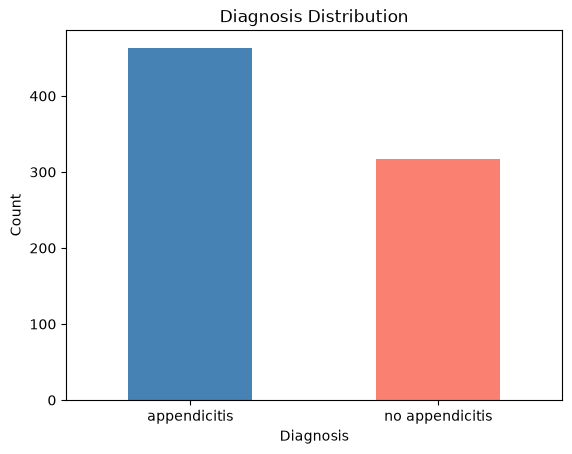

In [18]:
import matplotlib.pyplot as plt

# Bar plot of Diagnosis classes
df["Diagnosis"].value_counts().plot(kind="bar", color=["steelblue", "salmon"])
plt.title("Diagnosis Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

16 ['Age', 'BMI', 'Height', 'Weight', 'Length_of_Stay', 'Alvarado_Score', 'Paedriatic_Appendicitis_Score', 'Appendix_Diameter', 'Body_Temperature', 'WBC_Count', 'Neutrophil_Percentage', 'RBC_Count', 'Hemoglobin', 'RDW', 'Thrombocyte_Count', 'CRP']


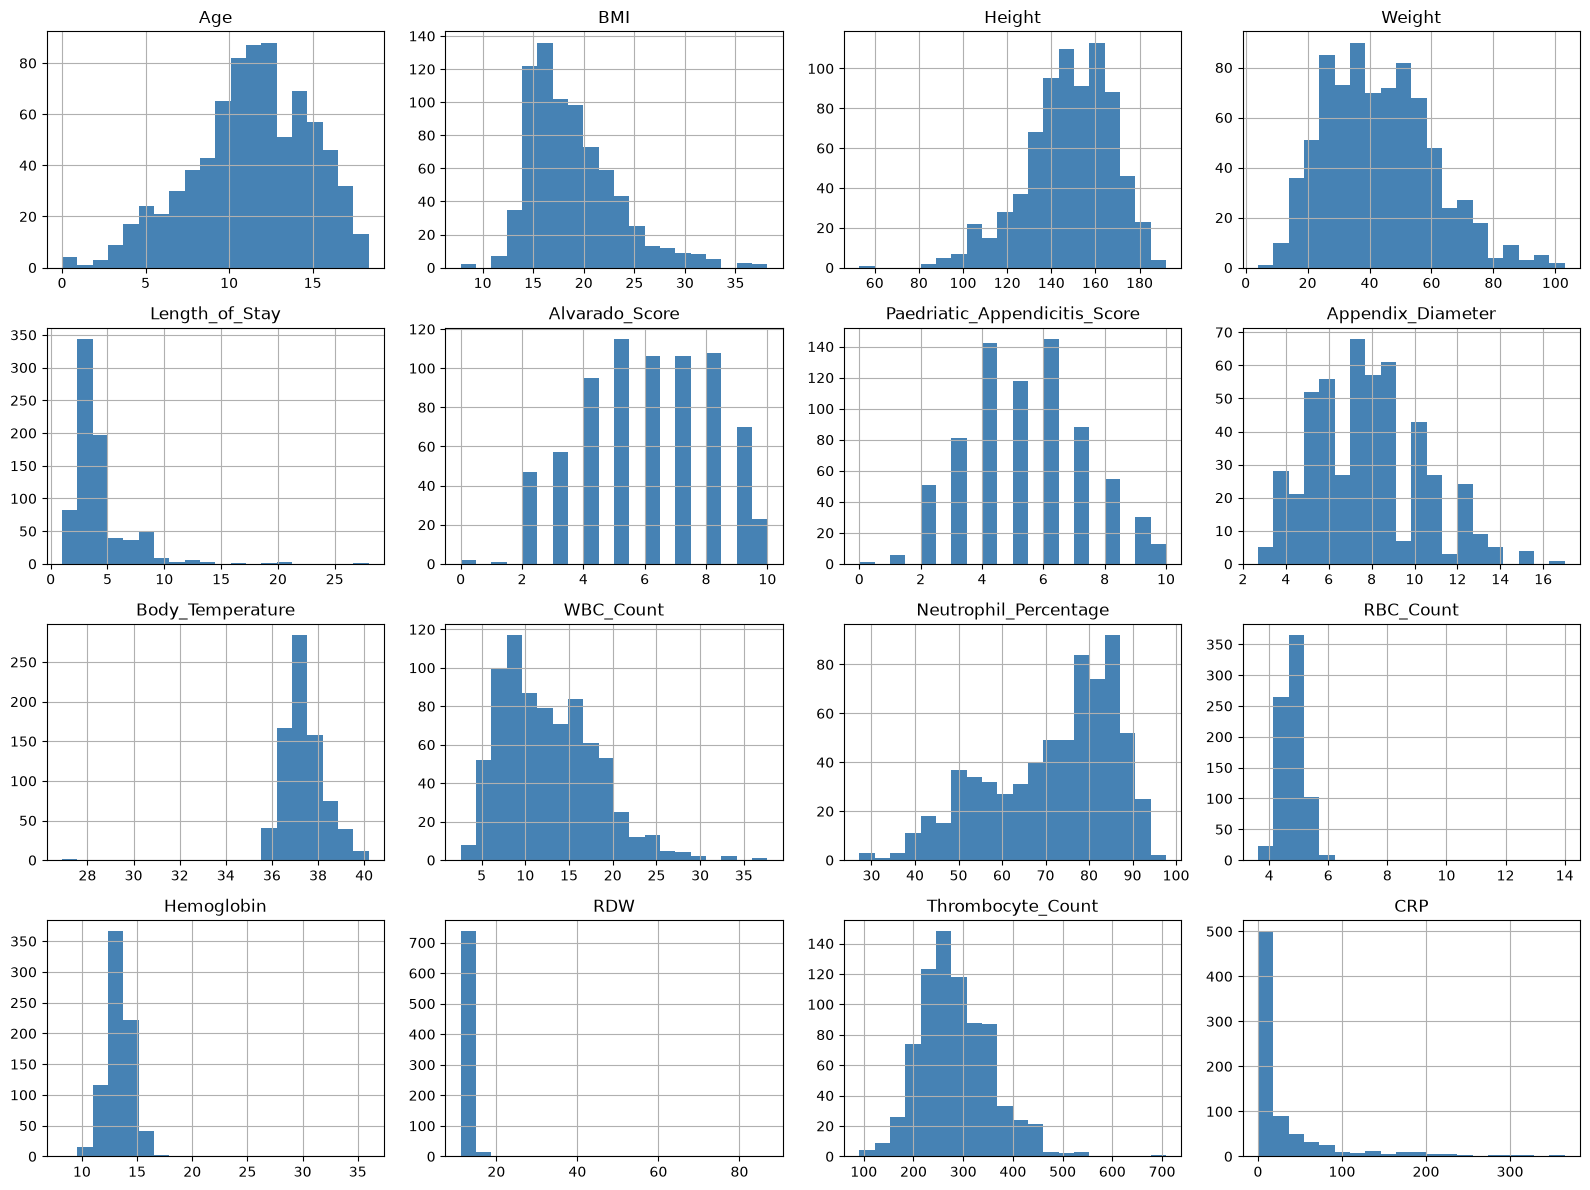

In [19]:
# Numerical columns only
num_cols = X.select_dtypes(include="number").columns.tolist()
print(len(num_cols), num_cols)

# Histogram for each numerical feature
df[num_cols].hist(bins=20, figsize=(16, 12), color="steelblue")
plt.tight_layout()
plt.show()

In [20]:
# Summary statistics of numerical features
print(df[num_cols].describe().T.round(2))

# Skewness values (positive = right-skewed, negative = left-skewed)
print(df[num_cols].skew().round(2))

                               count    mean    std    min     25%     50%  \
Age                            780.0   11.34   3.53   0.00    9.20   11.44   
BMI                            754.0   18.91   4.39   7.83   15.72   18.05   
Height                         755.0  148.00  19.74  53.00  137.00  149.50   
Weight                         778.0   43.16  17.40   3.96   29.50   41.30   
Length_of_Stay                 777.0    4.29   2.58   1.00    3.00    3.00   
Alvarado_Score                 730.0    5.92   2.16   0.00    4.00    6.00   
Paedriatic_Appendicitis_Score  730.0    5.25   1.96   0.00    4.00    5.00   
Appendix_Diameter              498.0    7.76   2.54   2.70    6.00    7.50   
Body_Temperature               775.0   37.40   0.90  26.90   36.80   37.20   
WBC_Count                      776.0   12.67   5.37   2.60    8.20   12.00   
Neutrophil_Percentage          679.0   71.79  14.46  27.20   61.40   75.50   
RBC_Count                      764.0    4.80   0.50   3.62    4.

In [21]:
# Count outliers per numerical feature using the IQR rule
for col in num_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    print(col, "->", n_out, "outliers")

Age -> 5 outliers
BMI -> 23 outliers
Height -> 12 outliers
Weight -> 8 outliers
Length_of_Stay -> 44 outliers
Alvarado_Score -> 0 outliers
Paedriatic_Appendicitis_Score -> 0 outliers
Appendix_Diameter -> 10 outliers
Body_Temperature -> 12 outliers
WBC_Count -> 6 outliers
Neutrophil_Percentage -> 1 outliers
RBC_Count -> 14 outliers
Hemoglobin -> 16 outliers
RDW -> 23 outliers
Thrombocyte_Count -> 9 outliers
CRP -> 85 outliers


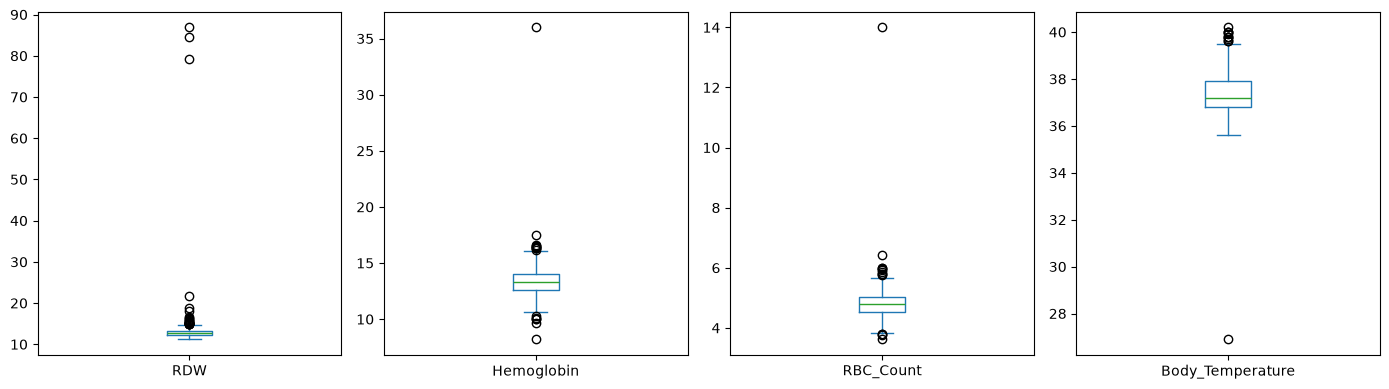

In [22]:
# Boxplots of columns with impossible-looking values
suspect_cols = ["RDW", "Hemoglobin", "RBC_Count", "Body_Temperature"]

df[suspect_cols].plot(kind="box", subplots=True, layout=(1, 4), figsize=(14, 4))
plt.tight_layout()
plt.show()

In [23]:
# Count impossible values (fixed medical limits, not learned from data)
print("RDW > 30:", (df["RDW"] > 30).sum())
print("Hemoglobin > 20:", (df["Hemoglobin"] > 20).sum())
print("RBC_Count > 8:", (df["RBC_Count"] > 8).sum())
print("Body_Temperature < 30:", (df["Body_Temperature"] < 30).sum())

# Replace them with NaN so imputation handles them later
df.loc[df["RDW"] > 30, "RDW"] = np.nan
df.loc[df["Hemoglobin"] > 20, "Hemoglobin"] = np.nan
df.loc[df["RBC_Count"] > 8, "RBC_Count"] = np.nan
df.loc[df["Body_Temperature"] < 30, "Body_Temperature"] = np.nan

print(df[suspect_cols].describe().T.round(2))

RDW > 30: 3
Hemoglobin > 20: 1
RBC_Count > 8: 1
Body_Temperature < 30: 1
                  count   mean   std    min    25%    50%    75%    max
RDW               753.0  12.90  0.89  11.20  12.30  12.70  13.30  21.60
Hemoglobin        763.0  13.35  1.13   8.20  12.60  13.30  14.00  17.50
RBC_Count         763.0   4.79  0.37   3.62   4.54   4.78   5.02   6.44
Body_Temperature  774.0  37.42  0.82  35.60  36.80  37.20  37.90  40.20


In [24]:
# Re-split because df changed after the earlier split
X = df.drop(columns=["Diagnosis", "Management", "Severity"])
y = df["Diagnosis"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))
print(X_train[suspect_cols].max().round(2))

Training rows: 624
Testing rows: 156
RDW                 21.6
Hemoglobin          17.5
RBC_Count            6.0
Body_Temperature    40.2
dtype: float64


In [25]:
# Categorical columns in the features
cat_cols = X.select_dtypes(exclude="number").columns.tolist()
print(len(cat_cols), cat_cols)

# Unique values per categorical column
for col in cat_cols:
    print(col, "->", X[col].unique())

20 ['Sex', 'Appendix_on_US', 'Migratory_Pain', 'Lower_Right_Abd_Pain', 'Contralateral_Rebound_Tenderness', 'Coughing_Pain', 'Nausea', 'Loss_of_Appetite', 'Neutrophilia', 'Ketones_in_Urine', 'RBC_in_Urine', 'WBC_in_Urine', 'Dysuria', 'Stool', 'Peritonitis', 'Psoas_Sign', 'Ipsilateral_Rebound_Tenderness', 'US_Performed', 'Free_Fluids', 'Surrounding_Tissue_Reaction']
Sex -> <ArrowStringArray>
['female', 'male', nan]
Length: 3, dtype: str
Appendix_on_US -> <ArrowStringArray>
['yes', 'no', nan]
Length: 3, dtype: str
Migratory_Pain -> <ArrowStringArray>
['no', 'yes', nan]
Length: 3, dtype: str
Lower_Right_Abd_Pain -> <ArrowStringArray>
['yes', 'no', nan]
Length: 3, dtype: str
Contralateral_Rebound_Tenderness -> <ArrowStringArray>
['yes', 'no', nan]
Length: 3, dtype: str
Coughing_Pain -> <ArrowStringArray>
['no', 'yes', nan]
Length: 3, dtype: str
Nausea -> <ArrowStringArray>
['no', 'yes', nan]
Length: 3, dtype: str
Loss_of_Appetite -> <ArrowStringArray>
['yes', 'no', nan]
Length: 3, dtype: st

In [26]:
# Group categorical columns by encoding type
ordinal_urine = ["Ketones_in_Urine", "RBC_in_Urine", "WBC_in_Urine"]
ordinal_peritonitis = ["Peritonitis"]
nominal_cols = ["Stool"]
binary_cols = [col for col in cat_cols
               if col not in ordinal_urine + ordinal_peritonitis + nominal_cols]

print(len(binary_cols), binary_cols)
print(len(ordinal_urine) + len(ordinal_peritonitis) + len(nominal_cols) + len(binary_cols))

15 ['Sex', 'Appendix_on_US', 'Migratory_Pain', 'Lower_Right_Abd_Pain', 'Contralateral_Rebound_Tenderness', 'Coughing_Pain', 'Nausea', 'Loss_of_Appetite', 'Neutrophilia', 'Dysuria', 'Psoas_Sign', 'Ipsilateral_Rebound_Tenderness', 'US_Performed', 'Free_Fluids', 'Surrounding_Tissue_Reaction']
20


In [27]:
# Binary mapping for the target: appendicitis = 1, no appendicitis = 0
y_train = y_train.map({"no appendicitis": 0, "appendicitis": 1})
y_test = y_test.map({"no appendicitis": 0, "appendicitis": 1})

print(y_train.value_counts())
print(y_test.value_counts())

Diagnosis
1    370
0    254
Name: count, dtype: int64
Diagnosis
1    93
0    63
Name: count, dtype: int64


In [28]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Numerical columns (defined earlier as num_cols)
numeric_features = num_cols

numeric_pipeline = Pipeline(steps=[
    # Step 1: Replace missing values with the median
    ("imputer", SimpleImputer(strategy="median")),

    # Step 2: Standardise the completed values
    ("scaler", StandardScaler())
])

print(len(numeric_features), numeric_features)

16 ['Age', 'BMI', 'Height', 'Weight', 'Length_of_Stay', 'Alvarado_Score', 'Paedriatic_Appendicitis_Score', 'Appendix_Diameter', 'Body_Temperature', 'WBC_Count', 'Neutrophil_Percentage', 'RBC_Count', 'Hemoglobin', 'RDW', 'Thrombocyte_Count', 'CRP']


In [29]:
from sklearn.preprocessing import OneHotEncoder

binary_pipeline = Pipeline(steps=[
    # Step 1: Replace missing values with the most frequent category
    ("imputer", SimpleImputer(strategy="most_frequent")),

    # Step 2: One column per feature (drop="if_binary" keeps a single 0/1 column)
    ("encoder", OneHotEncoder(drop="if_binary", handle_unknown="ignore"))
])

print(len(binary_cols))

15


In [30]:
from sklearn.preprocessing import OrdinalEncoder

# Order: no < + < ++ < +++
urine_order = ["no", "+", "++", "+++"]

urine_pipeline = Pipeline(steps=[
    # Step 1: Replace missing values with the most frequent category
    ("imputer", SimpleImputer(strategy="most_frequent")),

    # Step 2: Encode in the natural order (one order list per column)
    ("encoder", OrdinalEncoder(
        categories=[urine_order] * len(ordinal_urine),
        handle_unknown="use_encoded_value",
        unknown_value=-1
    ))
])

print(ordinal_urine)

['Ketones_in_Urine', 'RBC_in_Urine', 'WBC_in_Urine']


In [31]:
# Order: no < local < generalized
peritonitis_order = ["no", "local", "generalized"]

peritonitis_pipeline = Pipeline(steps=[
    # Step 1: Replace missing values with the most frequent category
    ("imputer", SimpleImputer(strategy="most_frequent")),

    # Step 2: Encode in the natural order
    ("encoder", OrdinalEncoder(
        categories=[peritonitis_order],
        handle_unknown="use_encoded_value",
        unknown_value=-1
    ))
])

print(ordinal_peritonitis)

['Peritonitis']


In [32]:
nominal_pipeline = Pipeline(steps=[
    # Step 1: Replace missing values with the most frequent category
    ("imputer", SimpleImputer(strategy="most_frequent")),

    # Step 2: One-hot encode (no order between categories)
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

print(nominal_cols)

['Stool']


In [33]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(transformers=[
    ("numeric", numeric_pipeline, numeric_features),
    ("binary", binary_pipeline, binary_cols),
    ("urine", urine_pipeline, ordinal_urine),
    ("peritonitis", peritonitis_pipeline, ordinal_peritonitis),
    ("nominal", nominal_pipeline, nominal_cols)
])

# Learn from training data only, then apply to test data
X_train_ready = preprocessor.fit_transform(X_train)
X_test_ready = preprocessor.transform(X_test)

print("Prepared training shape:", X_train_ready.shape)
print("Prepared testing shape:", X_test_ready.shape)

Prepared training shape: (624, 39)
Prepared testing shape: (156, 39)
